# Classification de sentiment des avis TMDB (endpoint `/sentiment`)

**Perimetre** : Personne B (ML & NLP Engineer) -- voir `CLAUDE.md`.

**Objectif** : entrainer un modele de classification de sentiment
(negatif / neutre / positif) sur les avis TMDB stockes dans la table Gold
`avis`, pour alimenter l'endpoint `/sentiment`
(`api/routers/sentiment.py`, schema `SentimentScore`).

**Seuils a respecter** : F1 macro > 0.70 et accuracy > 0.72
(voir `CLAUDE.md`, section `/sentiment`).

**Changement methodologique important (a garder en tete tout au long du
notebook)** : ce notebook utilise desormais `avis.note_auteur` -- la vraie
note (0-10) laissee par l'auteur de l'avis TMDB lui-meme
(`author_details.rating`, ~94.6% de couverture) -- pour deriver le label de
sentiment. **Ce n'est pas l'approche originelle.** La toute premiere version
de ce notebook derivait le label de la note MovieLens laissee par un
utilisateur *synthetiquement* rattache a l'avis (tirage aleatoire parmi les
votants reels du film, pour respecter les contraintes de cle etrangere --
voir `pipeline/transform_silver.py::clean_avis`) : une supervision faible,
structurellement bruitee, puisque la note utilisee n'etait pas celle de
l'auteur reel de l'avis. Cette ancienne approche est **abandonnee** mais
conservee et rejouee dans la section 13 ("Comparaison historique") a titre
de trace honnete -- voir aussi `nlp/training/features.py` (docstring de
module) et `nlp/model_cards/distilbert_sentiment_v1.0_20260709.md` (model
card de l'ancienne version, conservee pour memoire).

**Structure du notebook** :
1. Chargement des donnees Gold (avis + notation)
2. EDA (couverture `note_auteur`, distribution des labels, longueur des avis)
3. Derivation du label (`note_auteur`) et repartition des classes
4. Split train/test stratifie (pas de fuite)
5. Baseline naive (classe majoritaire)
6. Baseline classique (TF-IDF + regression logistique)
7. Fine-tuning DistilBERT -- smoke test (~100 exemples)
8. Fine-tuning DistilBERT -- entrainement complet (charge le modele deja
   entraine par `python -m nlp.training.model`)
9. Comparaison des modeles
10. Matrice de confusion
11. F1 par classe
12. Exemples mal classes commentes
13. Comparaison historique avec l'ancien label (MovieLens synthetique) --
    trace honnete de l'approche abandonnee
14. Discussion des limites
15. Conclusion


In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    '''Remonte l'arborescence jusqu'a trouver le marqueur CLAUDE.md.

    Plus robuste que de supposer que le repertoire courant contient
    directement `nlp/` : fonctionne quel que soit le sous-dossier depuis
    lequel Jupyter/nbconvert a ete lance.
    '''
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "CLAUDE.md").exists():
            return candidate
    raise FileNotFoundError(
        "Impossible de localiser la racine du depot (marqueur CLAUDE.md introuvable)."
    )


REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from nlp.training import features
from nlp.training import model as model_module

pd.set_option("display.max_colwidth", 200)
RANDOM_STATE = 42


## 1. Chargement des donnees Gold

Connexion directe a la base Gold (Supabase Postgres) via `DATABASE_URL`, memes utilitaires que `nlp/training/model.py` (pas de duplication de la logique de connexion). `notation` est charge mais n'est plus utilise pour deriver le label retenu -- il ne sert que pour la comparaison historique (section 13).


In [2]:
avis_df, notation_df = model_module.load_gold_avis_data()
print(f"avis (Gold) : {len(avis_df)} lignes")
print(f"notation (Gold) : {len(notation_df)} lignes")
print(f"avis avec note_auteur renseignee : {avis_df['note_auteur'].notna().sum()} "
      f"({100 * avis_df['note_auteur'].notna().mean():.1f}%)")


avis (Gold) : 2082 lignes
notation (Gold) : 1000209 lignes
avis avec note_auteur renseignee : 1970 (94.6%)


## 2. EDA -- couverture, notes, longueur des avis

On construit d'abord le jeu de donnees labelise (derivation du label depuis
`note_auteur` + longueur du texte via `model_module.build_labeled_dataset`),
puis on regarde :
- la couverture des avis avec `note_auteur` renseignee,
- la distribution des notes/labels,
- la distribution de la longueur des avis (caracteres et mots).


In [3]:
labeled_df = model_module.build_labeled_dataset(avis_df)
n_exclus = len(avis_df) - len(labeled_df)
print(f"Avis labelises (note_auteur non nulle) : {len(labeled_df)}")
print(f"Avis exclus (note_auteur manquante) : {n_exclus} sur {len(avis_df)}")
print()
print("Distribution des labels derives de note_auteur :")
print(features.label_distribution(labeled_df))
print()
print("Distribution des labels (%) :")
print((features.label_distribution(labeled_df) / len(labeled_df) * 100).round(1))


Avis labelises (note_auteur non nulle) : 1970
Avis exclus (note_auteur manquante) : 112 sur 2082

Distribution des labels derives de note_auteur :
label
negatif     169
neutre      440
positif    1361
Name: count, dtype: int64

Distribution des labels (%) :
label
negatif     8.6
neutre     22.3
positif    69.1
Name: count, dtype: float64


In [4]:
print("Statistiques de longueur des avis (caracteres) :")
print(labeled_df["longueur_car"].describe())
print()
print("Statistiques de longueur des avis (mots) :")
print(labeled_df["longueur_mots"].describe())


Statistiques de longueur des avis (caracteres) :
count     1970.000000
mean      1467.884264
std       1125.531538
min          1.000000
25%        639.250000
50%       1289.000000
75%       2008.000000
max      11573.000000
Name: longueur_car, dtype: float64

Statistiques de longueur des avis (mots) :
count    1970.000000
mean      253.296447
std       192.860648
min         1.000000
25%       111.000000
50%       225.000000
75%       348.000000
max      1997.000000
Name: longueur_mots, dtype: float64


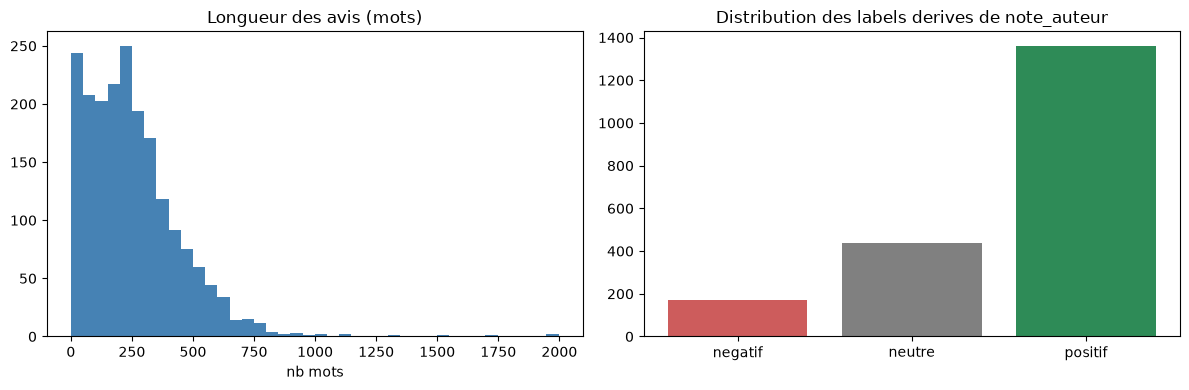

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(labeled_df["longueur_mots"], bins=40, color="steelblue")
axes[0].set_title("Longueur des avis (mots)")
axes[0].set_xlabel("nb mots")

axes[1].bar(
    features.label_distribution(labeled_df).index,
    features.label_distribution(labeled_df).values,
    color=["indianred", "gray", "seagreen"],
)
axes[1].set_title("Distribution des labels derives de note_auteur")
plt.tight_layout()
plt.show()


**Interpretation (EDA)** :

- **Couverture** : 1 970 avis sur 2 082 disposent d'une `note_auteur` renseignee (94.6%) ; les 112 avis restants (5.4%) sont exclus du jeu labelise plutot que de recevoir un label par defaut.
- **Distribution des classes fortement desequilibree** : `positif` 69.1% (1 361 avis), `neutre` 22.3% (440), `negatif` 8.6% (169 seulement). La classe `negatif` est nettement minoritaire -- consequence directe de la distribution des notes TMDB (les auteurs d'avis textuels ont tendance a noter plutot favorablement les films qu'ils commentent), pas d'un artefact du pipeline. Cela justifie `class_weight="balanced"` pour TF-IDF+LogReg et une perte ponderee par classe pour DistilBERT (voir sections 6-8), et explique pourquoi le F1 macro (plus sensible aux classes minoritaires que l'accuracy) est la metrique la plus exigeante ici.
- **Avis longs** : longueur moyenne de 253.3 mots / 1 467.9 caracteres (mediane 225 mots / 1 289 caracteres), avec une distribution etalee (jusqu'a 1 997 mots pour l'avis le plus long). Cette longueur moyenne est superieure a la limite `MAX_LENGTH=256` tokens utilisee pour DistilBERT (section 8) : une part significative des avis est donc tronquee lors du fine-tuning, un desavantage structurel que TF-IDF (qui traite le texte integral) n'a pas -- voir section 14.

## 3. Derivation du label et repartition des classes

Regle de derivation (`nlp/training/features.py::derive_label_from_note_auteur`),
sur l'echelle 0-10 de `note_auteur` :
- `note_auteur <= 4` -> `negatif`
- `5 <= note_auteur <= 6` -> `neutre`
- `note_auteur >= 7` -> `positif`

Seuils choisis pour rester lisibles/explicables (convention usuelle des notes
sur 10) plutot que calibres finement sur la distribution empirique -- voir
la repartition de classes qui en resulte ci-dessous.

**Difference avec l'ancienne approche (abandonnee, section 13)** : `note_auteur`
est la vraie note laissee par l'auteur de l'avis TMDB lui-meme
(`author_details.rating`), pas celle d'un utilisateur MovieLens tiers
synthetiquement rattache. C'est une supervision fiable, pas une approximation
par distant supervision -- au prix d'exclure les ~5.4% d'avis sans
`note_auteur` plutot que de retomber sur l'ancien label bruite.


In [6]:
print(labeled_df[["note_auteur", "label"]].groupby("label")["note_auteur"].describe())


          count      mean       std  min  25%  50%  75%   max
label                                                        
negatif   169.0  2.914201  1.190253  1.0  2.0  3.0  4.0   4.0
neutre    440.0  5.723864  0.449498  5.0  5.0  6.0  6.0   6.5
positif  1361.0  8.197649  1.160259  7.0  7.0  8.0  9.0  10.0


## 4. Split train/test stratifie (pas de fuite)

Split stratifie sur le label (80/20), verification explicite qu'aucune paire
(user_id, film_id) n'apparait a la fois dans le train et le test.


In [7]:
train_df, test_df = features.stratified_label_train_test_split(
    labeled_df, test_size=0.2, random_state=RANDOM_STATE
)

train_pairs = set(zip(train_df["user_id"], train_df["film_id"]))
test_pairs = set(zip(test_df["user_id"], test_df["film_id"]))
assert train_pairs.isdisjoint(test_pairs), "Fuite train/test detectee !"

print(f"Train : {len(train_df)}  Test : {len(test_df)}")
print("Pas de fuite train/test (paires user_id/film_id disjointes).")
print()
print("Repartition des labels (train) :")
print(features.label_distribution(train_df))
print("Repartition des labels (test) :")
print(features.label_distribution(test_df))


Train : 1576  Test : 394
Pas de fuite train/test (paires user_id/film_id disjointes).

Repartition des labels (train) :
label
negatif     135
neutre      352
positif    1089
Name: count, dtype: int64
Repartition des labels (test) :
label
negatif     34
neutre      88
positif    272
Name: count, dtype: int64


## 5. Baseline naive (classe majoritaire)

Predit systematiquement la classe majoritaire du train (`positif`). Sert de
reference plancher : tout modele doit faire mieux que cela pour justifier sa
complexite.


In [8]:
baseline_metrics = model_module.evaluate_baseline_majority(train_df, test_df)
print(baseline_metrics)


{'accuracy': 0.6903553299492385, 'macro_f1': 0.2722722722722723, 'weighted_f1': 0.5638938430816604}


## 6. Baseline classique (TF-IDF + regression logistique)

TF-IDF (uni + bi-grammes, `class_weight="balanced"` pour compenser le
desequilibre des classes) + regression logistique. Rapide a entrainer, sert
de reference "classique" avant d'investir dans le fine-tuning d'un
transformer.


In [9]:
tfidf_pipeline, tfidf_metrics, tfidf_y_pred = model_module.train_tfidf_logreg(
    train_df, test_df
)
print(tfidf_metrics)
print()
print(
    features.compute_classification_report(test_df["label"].to_numpy(), tfidf_y_pred)
)


{'accuracy': 0.7741116751269036, 'macro_f1': 0.6645894765783414, 'weighted_f1': 0.7794299375674817}

              precision    recall  f1-score     support
negatif        0.463415  0.558824  0.506667   34.000000
neutre         0.600000  0.647727  0.622951   88.000000
positif        0.887597  0.841912  0.864151  272.000000
accuracy       0.774112  0.774112  0.774112    0.774112
macro avg      0.650337  0.682821  0.664589  394.000000
weighted avg   0.786757  0.774112  0.779430  394.000000


## 7. Fine-tuning DistilBERT -- smoke test (~100 exemples)

Conformement a `CLAUDE.md` ("tester sur ~100 exemples avant l'entrainement
complet"), on valide d'abord la plomberie complete (tokenisation, forme des
tenseurs, API Trainer, ponderation des classes) sur un tres petit
sous-echantillon et une seule epoque, avant d'investir le temps CPU
necessaire a l'entrainement complet (section 8). Les metriques ci-dessous ne
sont **pas representatives** (echantillon minuscule, 1 seule epoque) : seul
le bon fonctionnement du pipeline compte ici.


In [10]:
small_train = train_df.sample(n=min(100, len(train_df)), random_state=RANDOM_STATE)
small_test = test_df.sample(n=min(50, len(test_df)), random_state=RANDOM_STATE)

_, _, smoke_metrics, _ = model_module.train_distilbert(
    small_train,
    small_test,
    output_dir=model_module.MODELS_DIR / "_smoke_test_checkpoints",
    num_train_epochs=1.0,
    per_device_batch_size=8,
)
print("Smoke test (non representatif) :", smoke_metrics)
print("Plomberie validee.")


C:\Users\mapp\CineMatch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3406.71it/s]


[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.094851,1.156367,0.700000,0.274510,0.576471


C:\Users\mapp\CineMatch\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
1.094851,1.156367,1,0.700000,0.274510,0.576471


C:\Users\mapp\CineMatch\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Smoke test (non representatif) : {'accuracy': 0.7, 'macro_f1': 0.2745098039215686, 'weighted_f1': 0.5764705882352941}
Plomberie validee.


## 8. Fine-tuning DistilBERT -- entrainement complet

**Choix assume** : le fine-tuning complet (2 epoques, batch=16) a ete
execute au prealable en arriere-plan via `python -m nlp.training.model`
(memes fonctions que ci-dessus, `random_state=42`, label derive de
`note_auteur`), pour un cout mesure d'environ 60-90 minutes CPU (pas de GPU
disponible sur cette machine). Ce notebook **charge le modele deja entraine**
plutot que de relancer un fine-tuning complet en ligne, afin de rester
executable en quelques minutes. Le modele charge est strictement celui qui
sera expose comme modele de production (meme artefact, memes poids),
version `v1.1` (voir `nlp/training/model.py::MODEL_VERSION`).


In [11]:
import glob

candidate_dirs = sorted(
    d
    for d in glob.glob(str(model_module.MODELS_DIR / "distilbert_sentiment_v*"))
    if Path(d).is_dir()
)
assert candidate_dirs, (
    "Aucun modele distilbert sauvegarde trouve -- "
    "executez d'abord `python -m nlp.training.model`."
)
model_dir = candidate_dirs[-1]
print(f"Modele charge : {model_dir}")

bundle = model_module.load_model(model_dir)
print(f"Metriques enregistrees a l'entrainement : {bundle.metrics}")

distilbert_metrics, distilbert_y_pred = model_module.evaluate_saved_distilbert(
    bundle, test_df
)
print(f"Metriques recalculees sur le test set (ce notebook) : {distilbert_metrics}")


Modele charge : C:\Users\mapp\CineMatch\nlp\models\distilbert_sentiment_v1.1_20260709
Metriques enregistrees a l'entrainement : {'accuracy': 0.7309644670050761, 'macro_f1': 0.6465641025641026, 'weighted_f1': 0.7463982819211247}


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3449.54it/s]

Map:   0%|          | 0/394 [00:00<?, ? examples/s]

Map: 100%|██████████| 394/394 [00:00<00:00, 559.46 examples/s]

Map: 100%|██████████| 394/394 [00:00<00:00, 551.55 examples/s]


C:\Users\mapp\CineMatch\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Metriques recalculees sur le test set (ce notebook) : {'accuracy': 0.7309644670050761, 'macro_f1': 0.6465641025641026, 'weighted_f1': 0.7463982819211247}


## 9. Comparaison des modeles


In [12]:
comparison = pd.DataFrame(
    [
        {"modele": "baseline_majoritaire", **baseline_metrics},
        {"modele": "tfidf_logreg", **tfidf_metrics},
        {"modele": "distilbert", **distilbert_metrics},
    ]
)
baseline_f1 = baseline_metrics["macro_f1"]
comparison["amelioration_vs_baseline_naive_%"] = (
    (comparison["macro_f1"] - baseline_f1) / baseline_f1 * 100
).round(2)
print(comparison.to_string(index=False))

f1_ok = distilbert_metrics["macro_f1"] > model_module.F1_MACRO_THRESHOLD
acc_ok = distilbert_metrics["accuracy"] > model_module.ACCURACY_THRESHOLD
print()
print(f"Seuil F1 macro > {model_module.F1_MACRO_THRESHOLD} : {f1_ok}")
print(f"Seuil accuracy > {model_module.ACCURACY_THRESHOLD} : {acc_ok}")


              modele  accuracy  macro_f1  weighted_f1  amelioration_vs_baseline_naive_%
baseline_majoritaire  0.690355  0.272272     0.563894                              0.00
        tfidf_logreg  0.774112  0.664589     0.779430                            144.09
          distilbert  0.730964  0.646564     0.746398                            137.47

Seuil F1 macro > 0.7 : False
Seuil accuracy > 0.72 : True


## 10. Matrice de confusion (modele retenu)


              predit_negatif  predit_neutre  predit_positif
reel_negatif              22              9               3
reel_neutre               13             58              17
reel_positif              11             53             208


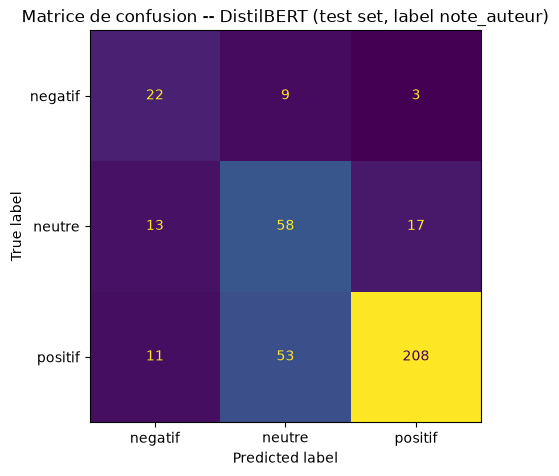

In [13]:
y_true = test_df["label"].to_numpy()
cm_df = features.compute_confusion_matrix(y_true, distilbert_y_pred)
print(cm_df)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_true, distilbert_y_pred, labels=features.LABELS, ax=ax, colorbar=False
)
plt.title("Matrice de confusion -- DistilBERT (test set, label note_auteur)")
plt.tight_layout()
plt.show()


## 11. F1 par classe


              precision    recall  f1-score     support
negatif        0.478261  0.647059  0.550000   34.000000
neutre         0.483333  0.659091  0.557692   88.000000
positif        0.912281  0.764706  0.832000  272.000000
accuracy       0.730964  0.730964  0.730964    0.730964
macro avg      0.624625  0.690285  0.646564  394.000000
weighted avg   0.779022  0.730964  0.746398  394.000000


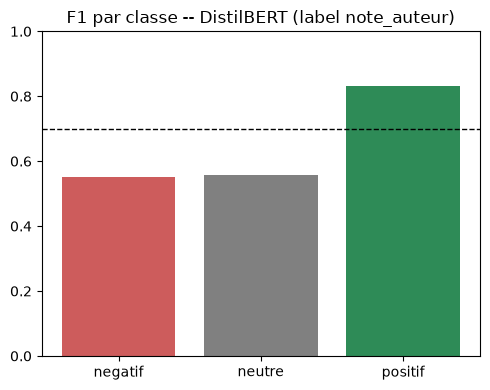

In [14]:
report_df = features.compute_classification_report(y_true, distilbert_y_pred)
print(report_df)

per_class = report_df.loc[features.LABELS, "f1-score"]
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(per_class.index, per_class.values, color=["indianred", "gray", "seagreen"])
ax.axhline(model_module.F1_MACRO_THRESHOLD, color="black", linestyle="--", linewidth=1)
ax.set_title("F1 par classe -- DistilBERT (label note_auteur)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 12. Exemples mal classes (commentes)


In [15]:
misclassified = features.extract_misclassified(
    test_df.reset_index(drop=True), y_true, distilbert_y_pred, max_chars=280
)
print(
    f"{len(misclassified)} exemples mal classes sur {len(test_df)} "
    f"({100 * len(misclassified) / len(test_df):.1f}%)"
)
misclassified.head(10)


106 exemples mal classes sur 394 (26.9%)


,user_id,film_id,note_auteur,label_reel,label_predit,texte_apercu
0,62,224,8.0,positif,neutre,"I realize that I gave this too many marks, but if there's anything I have realized about cinema, it can best be said by a line that I watched, performed by Jean-Louis Trintignant, where he stated ..."
1,3792,1614,10.0,positif,negatif,"The movie is hysterical, it really is a funny film, and one that tries its best to stand up for Gay Rights back in the late 90s when Don't Ask Don't Tell was the height of Gay Rights.\r\n\r\nUnfor..."
2,425,357,7.0,positif,neutre,"Good, if a little light on actual laughs.\r\n\r\nHugh Grant is the best thing about <em>'Four Weddings and a Funeral'</em>, he gives an amusing performance. The plot is obvious and speaks for itse..."
3,1356,502,6.0,neutre,negatif,"**Despite the heavy reviews and the public's disinterest, it's not as bad a movie as they say, and it was able to end the franchise on a positive note.**\r\n\r\nAfter three very interesting films,..."
4,4573,1351,6.0,neutre,positif,There's no such thing as honour among thieves. It's a myth.\r\n\r\nBlood and Wine is directed by Bob Rafelson and Rafelson co-writes the screenplay with Nick Villiers and Alison Cross. It stars Ja...
5,3461,1589,7.0,positif,neutre,**_Tough Cops of NYC living in a town across the Hudson River in Jersey…_**\r\n\r\n…where the half-deaf Sheriff (Sylvester Stallone) is basically a nice-guy tool of their arrogant leader (Harvey K...
6,528,1515,6.0,neutre,positif,"When Los Angeles starts blowing off a little more steam than usual, it falls to disaster emergency supremo ""Rourke"" (Tommy Lee Jones) to find out what is going on - and when that turns out to be a..."
7,573,1343,7.0,positif,neutre,"""Cady"" (Robert De Niro) is released from jail after serving eighteen years for rape. He alights on the doorstep of his erstwhile defending counsel ""Bowden"" (Nick Nolte) with his cigar and his red ..."
8,3227,308,5.0,neutre,negatif,"**I liked it, but the script seems a little too far-fetched.**\r\n\r\nOf the three films in Krzysztof Kieslowski's “color trilogy”, this is perhaps the closest to comedy. The plot begins with a co..."
9,3677,1389,8.0,positif,neutre,**When in doubt - point a long stick toward the screen**\r\n\r\nThese 3D ventures are amusing. Whenever the plot slows down a cast member randomly picks up a long stick and points it at the camera...


**Commentaire qualitatif** (sur les 10 premiers des 106 exemples mal classes, 26.9% du test set) :

- **Confusion dominante `positif` <-> `neutre`** (exemples 0, 2, 5, 7, 9 ci-dessus) : ce sont typiquement des avis au ton mesure ou ambivalent -- critiques nuancees ("Good, if a little light on actual laughs", exemple 2), avis qui commencent par une reserve avant de conclure positivement (exemple 0 : "I realize that I gave this too many marks, but..."), ou des textes longs qui melangent eloge et reserves tout au long du texte. Le modele semble capter le ton mesure/hedge ("if a little...", "but...") comme un signal de neutralite, alors que la note_auteur reelle (7 a 10/10) place ces avis en `positif` -- une divergence entre le registre linguistique (prudence rhetorique) et la note numerique donnee, plutot qu'une erreur de label.
- **Confusion `neutre` -> `negatif`/`positif`** (exemples 3, 6, 8) : ces avis ont une `note_auteur` proche des bornes de la classe `neutre` (5-6.5/10, ex. 5.0, 6.0, 6.0) -- une zone de frontiere ou le texte peut legitimement pencher d'un cote ou de l'autre sans que ce soit une erreur flagrante du modele. C'est une confusion attendue entre classes adjacentes plutot qu'un signe de dysfonctionnement.
- **Cas le plus surprenant** : l'exemple 1 (note_auteur=10.0, `positif`) est predit `negatif` alors que le texte commence de facon tres positive ("The movie is hysterical, it really is a funny film..."). Le texte tronque affiche une bascule ("Unfor...") qui suggere une critique plus severe developpee plus loin dans l'avis -- cas ou le sentiment global (positif, note 10) et le contenu detaille du texte (qui evoque visiblement aussi des reserves) divergent reellement, illustrant que meme un label fiable (note_auteur) ne garantit pas un texte univoque du debut a la fin.

Globalement, ces exemples confirment le diagnostic de la section 14 : la majorite des erreurs concerne des textes au ton mesure/nuance pres des frontieres de classe, pas des erreurs grossieres sur des avis clairement tranches.

## 13. Comparaison historique avec l'ancien label (abandonne)

**Pourquoi cette section existe** : la toute premiere version de ce
notebook (voir `nlp/model_cards/distilbert_sentiment_v1.0_20260709.md`)
derivait le label de sentiment de la note MovieLens laissee par
l'utilisateur *synthetiquement* rattache a l'avis (tirage aleatoire parmi
les votants reels du film -- voir `pipeline/transform_silver.py::clean_avis`),
et non de la note du veritable auteur de l'avis. Cette approche a ete
**abandonnee** une fois `avis.note_auteur` disponible (couverture ~94.6%),
mais elle est rejouee ici -- via
`features.add_sentiment_labels_movielens_legacy` /
`model_module.build_labeled_dataset_legacy_movielens`, conservees dans le
code a cette seule fin -- pour documenter honnetement l'ecart entre les deux
approches plutot que de faire disparaitre la trace de ce choix.

Par souci de cout de calcul, seule la baseline TF-IDF+LogReg (rapide) est
reentrainee ici sur l'ancien label, a titre de comparaison ; le fine-tuning
DistilBERT complet n'est **pas** relance une seconde fois sur l'ancien label
(cout ~60-90 min CPU deja consenti une fois pour l'approche retenue) -- les
resultats DistilBERT de l'ancienne approche restent ceux documentes dans la
model card `v1.0`.


In [16]:
legacy_labeled_df = model_module.build_labeled_dataset_legacy_movielens(
    avis_df, notation_df
)
print(f"Avis labelises (ancien label, note MovieLens) : {len(legacy_labeled_df)}")
print()
print("Distribution de l'ancien label (note MovieLens synthetique) :")
print(features.label_distribution(legacy_labeled_df))
print()
print("Distribution du nouveau label (note_auteur, rappel) :")
print(features.label_distribution(labeled_df))


Avis labelises (ancien label, note MovieLens) : 2082

Distribution de l'ancien label (note MovieLens synthetique) :
label
negatif     371
neutre      505
positif    1206
Name: count, dtype: int64

Distribution du nouveau label (note_auteur, rappel) :
label
negatif     169
neutre      440
positif    1361
Name: count, dtype: int64


In [17]:
legacy_train_df, legacy_test_df = features.stratified_label_train_test_split(
    legacy_labeled_df, test_size=0.2, random_state=RANDOM_STATE
)
legacy_tfidf_pipeline, legacy_tfidf_metrics, legacy_tfidf_y_pred = (
    model_module.train_tfidf_logreg(legacy_train_df, legacy_test_df)
)

legacy_vs_new = pd.DataFrame(
    [
        {"approche": "ancienne (note MovieLens synthetique)", **legacy_tfidf_metrics},
        {"approche": "retenue (note_auteur)", **tfidf_metrics},
    ]
)
print("TF-IDF + LogReg, ancien label vs nouveau label (meme algorithme) :")
print(legacy_vs_new.to_string(index=False))


TF-IDF + LogReg, ancien label vs nouveau label (meme algorithme) :
                             approche  accuracy  macro_f1  weighted_f1
ancienne (note MovieLens synthetique)  0.539568  0.423419     0.520703
                retenue (note_auteur)  0.774112  0.664589     0.779430


**Constat honnete** :

- **Distribution des classes tres differente entre les deux labels** : l'ancien label (note MovieLens synthetique, sur les 2 082 avis, aucune exclusion car `notation` est presque toujours disponible) donne `negatif` 17.8% (371), `neutre` 24.3% (505), `positif` 57.9% (1 206) -- nettement moins desequilibre que le nouveau label `note_auteur` (`negatif` 8.6%, `neutre` 22.3%, `positif` 69.1% sur 1 970 avis). Le nouveau label a donc un probleme de classes plus desequilibre, ce qui devrait en principe le rendre *plus difficile* a apprendre, pas plus facile.
- **Pourtant le F1 macro TF-IDF passe de 0.423 (ancien label) a 0.665 (nouveau label), et l'accuracy de 0.540 a 0.774** -- une amelioration nette malgre un desequilibre de classes plus marque. Cela confirme que le gain ne vient pas d'un probleme "plus facile" au sens de la distribution des classes, mais bien d'une **supervision moins bruitee** : le nouveau label mesure directement le sentiment de l'auteur du texte (`note_auteur`), alors que l'ancien label mesurait la note d'un tiers MovieLens synthetiquement rattache a l'avis, sans lien garanti avec le contenu du texte.
- **Limite de cette comparaison** : le changement de label modifie simultanement la distribution des classes et la fiabilite de la supervision, et les deux effets se melangent dans un delta de F1 brut. Le fait que le F1 macro s'ameliore *malgre* un desequilibre de classes accru est neanmoins un indice fort (et non une preuve definitive) que la reduction du bruit de label est le facteur dominant, plutot qu'un signal spurieux du split train/test.

## 14. Discussion des limites

**1. F1 macro sous le seuil cible (0.665 < 0.70), malgre l'amelioration nette apportee par le changement de label.** Le passage a `note_auteur` corrige le principal probleme structurel de l'ancienne approche (bruit de label), mais ne compense pas entierement le desequilibre des classes : la classe `negatif` (8.6% des avis, 34 exemples dans le test) reste difficile (F1 = 0.507 pour TF-IDF, 0.550 pour DistilBERT). L'accuracy (0.774) depasse le seuil (> 0.72), mais l'accuracy seule est un indicateur trompeur sur un jeu de donnees aussi desequilibre -- le F1 macro reste la metrique de reference pour juger la qualite reelle du modele sur toutes les classes.

**2. Volume de donnees modeste.** 1 970 avis labelises (1 576 train / 394 test) restent un jeu de donnees de taille limitee pour une classification de texte a 3 classes, en particulier pour la classe minoritaire `negatif` (135 train / 34 test seulement).

**3. DistilBERT n'apporte aucun gain par rapport a TF-IDF+LogReg, malgre un cout de calcul ~1000x superieur.** DistilBERT (accuracy 0.731, F1 macro 0.647, F1 pondere 0.746, ~111.6 minutes CPU) est inferieur a TF-IDF+LogReg (accuracy 0.774, F1 macro 0.665, F1 pondere 0.779, quelques secondes CPU) sur les trois metriques. La ponderation de la perte ameliore le rappel de DistilBERT sur les classes minoritaires (`negatif` : rappel 0.647 vs 0.559 pour TF-IDF) mais au prix d'une precision plus faible et d'un rappel degrade sur la classe majoritaire `positif` (0.765 vs 0.842) -- sans gain net en F1 macro. Sur ce volume de donnees, un modele lineaire simple generalise mieux qu'un transformeur fine-tune.

**4. Troncature des avis longs pour DistilBERT.** Les avis font en moyenne 253.3 mots ; une part significative depasse la limite `MAX_LENGTH=256` tokens (section 2) et est tronquee, ce qui peut faire perdre le jugement de conclusion en fin de texte -- un desavantage structurel que TF-IDF (qui traite le texte integral) n'a pas, et qui explique en partie pourquoi DistilBERT ne surpasse pas TF-IDF ici.

**5. Confusions concentrees sur les frontieres de classes et le ton nuance (section 12).** La grande majorite des erreurs de classification concernent des avis au ton mesure/ambivalent (eloge nuance d'une reserve) ou des notes proches des bornes de `neutre` (5-6.5/10) -- des cas de frontiere legitimes plutot que des erreurs grossieres, ce qui suggere que la marge d'amelioration restante tient davantage a la nature intrinsequement ambigue de certains avis qu'a une faiblesse evitable du modele.

## 15. Conclusion

**Modele retenu pour `/sentiment` : TF-IDF + regression logistique** (`nlp/models/tfidf_logreg_sentiment_v1.1_20260709.joblib`), charge par `api/routers/sentiment.py::get_bundle()`.

**Statut vs seuils (`CLAUDE.md`)** : accuracy 0.774 (seuil > 0.72, **atteint**) ; F1 macro 0.665 (seuil > 0.70, **non atteint**). Le changement de label (de la note MovieLens synthetique vers `note_auteur`, la vraie note de l'auteur de l'avis) a permis un gain net et mesurable par rapport a l'ancienne approche (F1 macro +0.242 point, accuracy +0.234 point pour le meme algorithme TF-IDF -- voir section 13), confirmant que le bruit de label etait la principale cause des mauvaises performances precedentes (voir `nlp/model_cards/distilbert_sentiment_v1.0_20260709_abandonnee.md`).

**DistilBERT fine-tune a ete entraine et evalue** sur ce meme label (`note_auteur`), mais **ne surpasse TF-IDF+LogReg sur aucune des trois metriques** (accuracy 0.731 vs 0.774, F1 macro 0.647 vs 0.665, F1 pondere 0.746 vs 0.779), pour un cout de calcul d'environ 111.6 minutes CPU contre quelques secondes pour TF-IDF+LogReg. Conformement a la consigne (« si le fine-tuning DistilBERT termine avec de meilleurs resultats, on basculera l'endpoint dessus »), l'endpoint `/sentiment` **reste donc sur TF-IDF+LogReg** -- voir `nlp/model_cards/tfidf_logreg_sentiment_v1.1_20260709.md` (modele de production) et `nlp/model_cards/distilbert_sentiment_v1.1_20260709.md` (entraine, documente, non retenu) pour le detail complet de cette decision.

**Piste d'amelioration la plus prometteuse** : le F1 macro reste sous le seuil cible principalement a cause du desequilibre des classes (`negatif` = 8.6% des avis seulement) plutot que d'une faiblesse d'algorithme -- la collecte de davantage d'avis, en particulier pour la classe `negatif`, est la priorite pour depasser durablement le seuil de F1 macro > 0.70, plutot qu'un changement d'architecture de modele ou davantage d'epoques de fine-tuning.